## Data Collecting

### Data Acquisition

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
file_path = '/content/drive/MyDrive/Project RPL/Dataset.csv'

df = pd.read_csv(file_path)

## Exploraty Data analysis (EDA)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   price     980 non-null    int64  
 1   location  980 non-null    object 
 2   bedrooms  965 non-null    float64
 3   toilet    973 non-null    float64
 4   garage    837 non-null    float64
 5   LT        956 non-null    float64
 6   LB        963 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 53.7+ KB


In [35]:
df.describe()

,price,bedrooms,toilet,garage,LT,LB
count,9.800000e+02,965.000000,973.000000,837.000000,9.560000e+02,963.000000
mean,6.690574e+09,4.104663,3.456321,2.025090,5.951614e+07,251.631646
std,1.162490e+10,11.201772,10.698515,1.771813,6.933367e+08,573.446796
min,8.620000e+07,1.000000,1.000000,1.000000,3.750000e-01,0.375000
25%,1.480000e+09,3.000000,2.000000,1.000000,7.200000e+01,77.000000
50%,2.800000e+09,3.000000,3.000000,2.000000,1.200000e+02,145.000000
75%,6.300000e+09,4.000000,4.000000,2.000000,2.210000e+02,281.500000
max,1.600000e+11,248.000000,237.000000,20.000000,8.128169e+09,11620.000000


In [36]:
df.duplicated().sum()

np.int64(252)

### Handling Duplicates

In [37]:
df[df.duplicated(keep=False)].head(10)


,price,location,bedrooms,toilet,garage,LT,LB
4,490000000,"Sawangan, Depok",2.0,1.0,1.0,72.0,50.0
6,3500000000,"Bintaro, Tangerang Selatan",4.0,3.0,2.0,120.0,140.0
29,1100000000,"Cikarang Selatan, Bekasi",3.0,3.0,1.0,64.0,72.0
39,990000000,"Jati Uwung, Tangerang",3.0,2.0,NaN,72.0,69.0
40,990000000,"Jati Uwung, Tangerang",3.0,2.0,NaN,72.0,69.0
72,1230000000,"Cikupa Citra Raya, Tangerang",3.0,2.0,1.0,120.0,136.0
73,21000000000,"Ampera, Jakarta Selatan",4.0,3.0,9.0,1034.0,500.0
74,1600000000,"Ciangsana, Bogor",4.0,3.0,1.0,100.0,185.0
207,5800000000,"Pantai Indah Kapuk, Jakarta Utara",4.0,3.0,2.0,175.0,250.0
208,19500000000,"Kelapa Gading, Jakarta Utara",5.0,5.0,4.0,513.0,800.0


In [38]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))


,price,location,bedrooms,toilet,garage,LT,LB
876,328000000,"Batuaji, Tabanan",2.0,1.0,NaN,60.0,60.0
900,328000000,"Batuaji, Tabanan",2.0,1.0,NaN,60.0,60.0
231,365000000,"Jonggol, Bogor",3.0,2.0,1.0,72.0,72.0
444,365000000,"Jonggol, Bogor",3.0,2.0,1.0,72.0,72.0
4,490000000,"Sawangan, Depok",2.0,1.0,1.0,72.0,50.0
...,...,...,...,...,...,...,...
718,53000000000,"Kebayoran Baru, Jakarta Selatan",5.0,3.0,5.0,726.0,564.0
311,53000000000,"Menteng, Jakarta Pusat",4.0,4.0,6.0,548.0,600.0
508,53000000000,"Menteng, Jakarta Pusat",4.0,4.0,6.0,548.0,600.0
346,54900000000,"Menteng, Jakarta Pusat",8.0,8.0,6.0,629.0,505.0


In [39]:
df = df.drop_duplicates()


In [40]:
print(df.duplicated().sum())


0


In [41]:
print("Total data setelah bersih:", len(df))

Total data setelah bersih: 728


## Data Preprocessing

### Handling Missing Values

In [42]:
missing_value = df.isnull().sum()
missing_value

,0
price,0
location,0
bedrooms,11
toilet,7
garage,129
LT,19
LB,15


In [43]:
df['bedrooms'].fillna(df['bedrooms'].median(), inplace=True)
df['toilet'].fillna(df['toilet'].median(), inplace=True)
df['garage'].fillna(df['garage'].median(), inplace=True)
df['LT'].fillna(df['LT'].median(), inplace=True)
df['LB'].fillna(df['LB'].median(), inplace=True)


In [44]:
print(df.isnull().sum())


price       0
location    0
bedrooms    0
toilet      0
garage      0
LT          0
LB          0
dtype: int64


### Correlation Analysis.

Matriks Korelasi:
             price  bedrooms    toilet    garage        LT        LB
price     1.000000  0.066398  0.080258  0.522316 -0.036087  0.317753
bedrooms  0.066398  1.000000  0.994770  0.038852 -0.012412  0.048653
toilet    0.080258  0.994770  1.000000  0.041502 -0.005757  0.054390
garage    0.522316  0.038852  0.041502  1.000000  0.002718  0.271119
LT       -0.036087 -0.012412 -0.005757  0.002718  1.000000 -0.020842
LB        0.317753  0.048653  0.054390  0.271119 -0.020842  1.000000


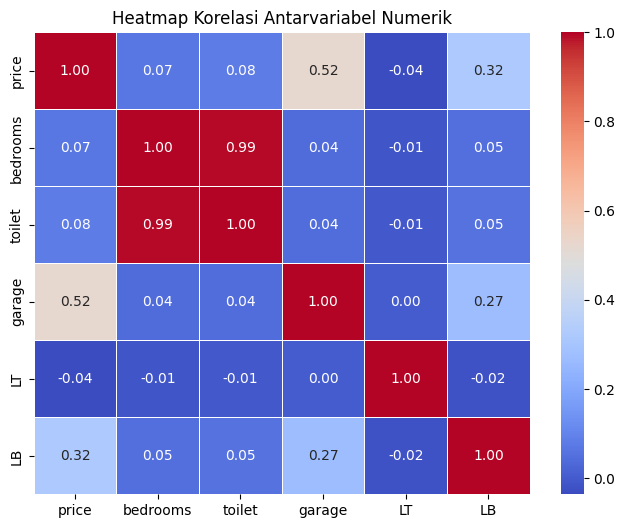

In [45]:
corr = df.corr(numeric_only=True)

print("Matriks Korelasi:")
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antarvariabel Numerik")
plt.show()

In [46]:
print("Korelasi setiap fitur terhadap harga (price):\n")
print(corr['price'].sort_values(ascending=False))


Korelasi setiap fitur terhadap harga (price):

price       1.000000
garage      0.522316
LB          0.317753
toilet      0.080258
bedrooms    0.066398
LT         -0.036087
Name: price, dtype: float64


### Outlier Detection

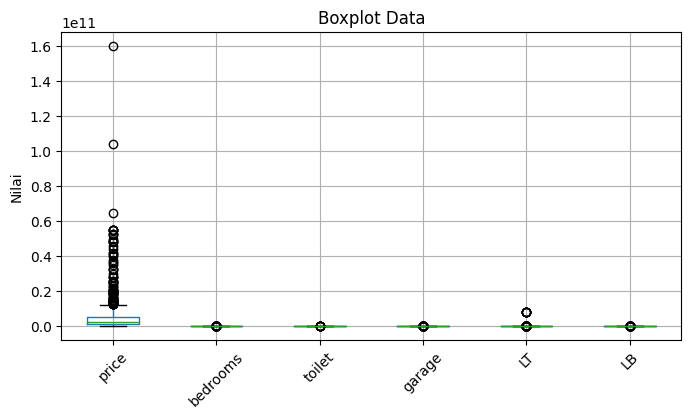

Data Outlier:
price       87
bedrooms    60
toilet       9
garage      69
LT          92
LB          61
dtype: int64


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
dataset = pd.DataFrame(df)
plt.figure(figsize=(8, 4))

cols_to_plot = ['price', 'bedrooms', 'toilet', 'garage', 'LT', 'LB']
dataset[cols_to_plot].boxplot()

# Menambahkan judul dan label sumbu y
plt.title('Boxplot Data')
plt.ylabel('Nilai')

# Mengatur label sumbu x
plt.xticks(ticks=range(1, len(cols_to_plot) + 1), labels=cols_to_plot, rotation=45)
plt.show()#


# Menghitung Q1, Q3, dan IQR untuk kolom numerik saja
Q1 = dataset[cols_to_plot].quantile(0.25)
Q3 = dataset[cols_to_plot].quantile(0.75)
IQR = Q3 - Q1

# Mengidentifikasi outliers
outliers = ((dataset[cols_to_plot] < (Q1 - 1.5 * IQR)) | (dataset[cols_to_plot] > (Q3 + 1.5 * IQR))).sum()

# Menampilkan jumlah outliers per kolom
print('Data Outlier:')
print(outliers)


### Encoding Location

In [48]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['location_encoded'] = le.fit_transform(df['location'])

In [49]:
print(df[['location', 'location_encoded']])

                              location  location_encoded
0         Kelapa Gading, Jakarta Utara               180
1    Pantai Indah Kapuk, Jakarta Utara               239
2                 Bekasi Utara, Bekasi                38
3             Kalideres, Jakarta Barat               161
4                      Sawangan, Depok               283
..                                 ...               ...
975                   Ketewel, Gianyar               185
976                   Seminyak, Badung               295
977                   Pasteur, Bandung               242
978                  Harjamukti, Depok               139
979                      Dago, Bandung               105

[728 rows x 2 columns]


### Splitting Features and Target

In [50]:
# fitur numerik + lokasi yang sudah di-encode
X = df[['bedrooms', 'toilet', 'garage', 'LT', 'LB', 'location_encoded']]

# Target harga rumah
y = df['price']

# 80% untuk training, 20% untuk testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Model Training using random forest

In [51]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model Random Forest berhasil dilatih!")


Model Random Forest berhasil dilatih!


In [52]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\nHASIL EVALUASI MODEL")
print(f"R² Score: {r2:.3f}")
print(f"Mean Absolute Error (Rp): {mae:,.0f}")



HASIL EVALUASI MODEL
R² Score: 0.618
Mean Absolute Error (Rp): 2,048,699,348


## Model Training using Bagging (Random Forest Regressor)

The process uses several models from the same algorithm, and trains each model on different samples from the same dataset. The predictions made by each model are then combined using simple statistics, such as voting or averaging.

In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    bootstrap=True,
    random_state=42
)

# Training
rf_model.fit(X_train, y_train)

# Prediction
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Evaluation
print("=== Bagging (Random Forest) ===")
print(f"Train R²: {r2_score(y_train, y_train_pred):.3f}")
print(f"Test  R²: {r2_score(y_test, y_test_pred):.3f}")
print(f"MAE: Rp {mean_absolute_error(y_test, y_test_pred):,.0f}")


=== Bagging (Random Forest) ===
Train R²: 0.790
Test  R²: 0.632
MAE: Rp 2,027,490,791


## Model Training using Boosting (XGBoost Regressor)

Boosting is a variation of bagging, where each individual model is built sequentially, repeating the previous one.In the process, each data point that was misclassified by the previous model is emphasized in the next model.

In [54]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Training
xgb_model.fit(X_train, y_train)

# Prediction
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# Evaluation
print("\n=== Boosting (XGBoost) ===")
print(f"Train R²: {r2_score(y_train, y_train_pred):.3f}")
print(f"Test  R²: {r2_score(y_test, y_test_pred):.3f}")
print(f"MAE: Rp {mean_absolute_error(y_test, y_test_pred):,.0f}")



=== Boosting (XGBoost) ===
Train R²: 0.999
Test  R²: 0.608
MAE: Rp 2,082,946,432


## Model Training using Stacking (Random Forest + XGBoost Linear Regression meta-model)

Stacking involves fitting many different types of models to the same data and using another model to learn how best to combine the predictions. In the process, each data point that was misclassified by the previous model is emphasized in the next model.

An ensemble technique that involves the use of a meta-learner model used to combine the prediction results from different machine learning models.

In [55]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

# Base models
base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=100, random_state=42))
]

# Meta model
meta_model = LinearRegression()

# Stacking Regressor
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

# Training
stacking_model.fit(X_train, y_train)

# Prediction
y_train_pred = stacking_model.predict(X_train)
y_test_pred = stacking_model.predict(X_test)

# Evaluation
print("\n=== Stacking (RF + XGB + LR Meta) ===")
print(f"Train R²: {r2_score(y_train, y_train_pred):.3f}")
print(f"Test  R²: {r2_score(y_test, y_test_pred):.3f}")
print(f"MAE: Rp {mean_absolute_error(y_test, y_test_pred):,.0f}")



=== Stacking (RF + XGB + LR Meta) ===
Train R²: 0.818
Test  R²: 0.640
MAE: Rp 2,144,786,224


## Model Evaluation

| Model | Train R² | Test R² | MAE (Rp) | Noted |
|:--|:--:|:--:|--:|:--|
| **Random Forest (awal)** | – | **0.618** | 2,048,699,348 | baseline model |
| **Bagging (Random Forest)** | 0.790 | **0.632** | 2,027,490,791 | stable performance, slightly better than baseline |
| **Boosting (XGBoost)** | 0.999 | **0.608** | 2,082,946,432 | overfitting (too good on train, poor on test)|
| **Stacking (RF + XGB + LR Meta)** | 0.818 | **0.640** | 2,144,786,224 | highest Test $R^2$, but MAE increased slightly|




Explanation

Model Performance Metrics

These metrics are used to evaluate the performance of the machine learning model:
- Train R²: Indicates how well the model explains the variation in the target variable within the training data.
- Test R²: Measures how well the model predicts unseen data
- MAE (Mean Absolute Error) : The average of the absolute differences between the predicted and actual prices. This metric is measured in rupiah (IDR).

Model Selection Justification

The Random Forest (Bagging) Model was chosen for the following reasons:

- It has a balanced Train $R^2$ and Test $R^2$, which signifies that the model is not overfitting the training data.
- It yielded a lower MAE compared to the XGBoost model and stacking model, indicating that its price predictions are more accurate